In [145]:
import numpy as np
import pandas as pd
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, GridSearchCV, cross_val_predict
)
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    mean_squared_error, accuracy_score,
    precision_score, recall_score, f1_score
)

from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

In [147]:
def compute_metrics(y_true, y_pred, label=""):
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec  = recall_score(y_true, y_pred)
    f1   = f1_score(y_true, y_pred)
    return {
        "Set": label,
        "MSE": round(mse, 4),
        "RMSE": round(rmse, 4),
        "Accuracy": round(acc, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1": round(f1, 4)
    }

In [149]:
def remove_outliers_iqr(df, features):
    for feature in features:
        Q1 = df[feature].quantile(0.25)
        Q3 = df[feature].quantile(0.75)
        IQR = Q3 - Q1
        df = df[(df[feature] >= Q1 - 1.5 * IQR) & (df[feature] <= Q3 + 1.5 * IQR)]
    return df

In [151]:
titanic_df = sns.load_dataset('titanic')
titanic_df = titanic_df[['age', 'fare', 'pclass', 'sex', 'survived']]
titanic_df["age"] = titanic_df["age"].fillna(titanic_df["age"].median())
titanic_df["fare"] = titanic_df["fare"].fillna(titanic_df["fare"].median()) 
titanic_df['sex'] = titanic_df['sex'].map({'male': 0, 'female': 1})
titanic_df = remove_outliers_iqr(titanic_df, ['age', 'fare'])
df = titanic_df.rename(columns={"survived": "target"})

X_train, X_test = train_test_split(df, test_size=0.2, random_state=2)

scaler = MinMaxScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=df.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=df.columns)
X_train = X_train_scaled.iloc[:, :-1]
X_test = X_test_scaled.iloc[:, :-1]
y_train = X_train_scaled.iloc[:, -1]
y_test = X_test_scaled.iloc[:, -1]

In [153]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

models = {
    "Naive Bayes": {
        "pipeline": Pipeline([
            ("scaler", MinMaxScaler()),
            ("clf", GaussianNB())
        ]),
        "params": {
            "clf__var_smoothing": np.logspace(-5, 5)
        }
    },

    "Logistic Regression": {
        "pipeline": Pipeline([
            ("scaler", MinMaxScaler()),
            ("clf", LogisticRegression(max_iter=100, random_state=2))
        ]),
        "params": {
            "clf__C": [0.1, 1]
        }
    },

    "Random Forest": {
        "pipeline": Pipeline([
            ("scaler", MinMaxScaler()),
            ("clf", RandomForestClassifier(random_state=2))
        ]),
        "params": {
            "clf__n_estimators": [50, 500],
            "clf__max_depth": [2, 10]
        }
    },

    "Neural Network": {
        "pipeline": Pipeline([
            ("scaler", MinMaxScaler()),
            ("clf", MLPClassifier(max_iter=500, random_state=2))
        ]),
        "params": {
            "clf__hidden_layer_sizes": [(10,), (20,), (50,), (10,10), (50,50)],
            "clf__activation": ["relu", "tanh"],
            "clf__solver": ['adam', 'sgd']
        }
    }
}

In [155]:
all_results = []

for name, config in models.items():
    print(f"\n{'='*60}")
    print(f"  Model: {name}")
    print(f"{'='*60}")

    gs = GridSearchCV(
        estimator=config["pipeline"],
        param_grid=config["params"],
        cv=cv,
        scoring='accuracy',
        n_jobs=-1,
        verbose=0
    )
    gs.fit(X_train, y_train)

    best_model = gs.best_estimator_
    print(f"  The best params : {gs.best_params_}")
    print(f"  CV F1 (val. set)   : {gs.best_score_:.4f}")

    y_train_pred = cross_val_predict(best_model, X_train, y_train, cv=cv)
    train_metrics = compute_metrics(y_train, y_train_pred, label="Train (CV)")

    y_test_pred = best_model.predict(X_test)
    test_metrics = compute_metrics(y_test, y_test_pred, label="Test")

    for m in [train_metrics, test_metrics]:
        print(f"\n  [{m['Set']}]")
        for k, v in m.items():
            if k != "Set":
                print(f"    {k:<12}: {v}")

    all_results.append({"Model": name, **train_metrics})
    all_results.append({"Model": name, **test_metrics})


  Model: Naive Bayes
  The best params : {'clf__var_smoothing': 0.7906043210907702}
  CV F1 (val. set)   : 0.7786

  [Train (CV)]
    MSE         : 0.2213
    RMSE        : 0.4704
    Accuracy    : 0.7787
    Precision   : 0.878
    Recall      : 0.381
    F1          : 0.5314

  [Test]
    MSE         : 0.2361
    RMSE        : 0.4859
    Accuracy    : 0.7639
    Precision   : 0.8696
    Recall      : 0.3922
    F1          : 0.5405

  Model: Logistic Regression
  The best params : {'clf__C': 1}
  CV F1 (val. set)   : 0.7681

  [Train (CV)]
    MSE         : 0.2317
    RMSE        : 0.4814
    Accuracy    : 0.7683
    Precision   : 0.6609
    Recall      : 0.6085
    F1          : 0.6336

  [Test]
    MSE         : 0.1458
    RMSE        : 0.3819
    Accuracy    : 0.8542
    Precision   : 0.7778
    Recall      : 0.8235
    F1          : 0.8

  Model: Random Forest
  The best params : {'clf__max_depth': 10, 'clf__n_estimators': 500}
  CV F1 (val. set)   : 0.7961

  [Train (CV)]
    M

In [156]:
print(f"\n\n{'='*60}")
print("Metrics")
print(f"{'='*60}")
df_results = pd.DataFrame(all_results)
df_results = df_results.set_index(["Model", "Set"])
print(df_results.to_string())



Metrics
                                   MSE    RMSE  Accuracy  Precision  Recall      F1
Model               Set                                                            
Naive Bayes         Train (CV)  0.2213  0.4704    0.7787     0.8780  0.3810  0.5314
                    Test        0.2361  0.4859    0.7639     0.8696  0.3922  0.5405
Logistic Regression Train (CV)  0.2317  0.4814    0.7683     0.6609  0.6085  0.6336
                    Test        0.1458  0.3819    0.8542     0.7778  0.8235  0.8000
Random Forest       Train (CV)  0.2038  0.4515    0.7962     0.7368  0.5926  0.6569
                    Test        0.1181  0.3436    0.8819     0.8400  0.8235  0.8317
Neural Network      Train (CV)  0.2125  0.4610    0.7875     0.7445  0.5397  0.6258
                    Test        0.1667  0.4082    0.8333     0.7755  0.7451  0.7600


In [110]:
def yes_function(x, y, a, kappa, lam, gamma=1):
    return 1 - np.maximum(0.0, ((1-x)**kappa + (1-y)**kappa - (1-a)**kappa))**(1/kappa)

def no_function(x, y, a, kappa, lam, gamma=1):
    return np.maximum(0.0, (x**lam + y**lam - a**lam))**(1/lam)

def maybe_function(x, y, a, kappa, lam, gamma=1):
    if x is None or y is None:
        return 0
    if gamma == 0:
        return 0
    a = np.clip(a, 1e-6, 1 - 1e-6)
    x = np.clip(x, 0, 1)
    y = np.clip(y, 0, 1)
    value = gamma*(1/a)*x*y + (1-gamma)*(1 - (1/(1-a))*(1-x)*(1-y))
    return np.clip(value, 0, 1)

def classification(x, y, a, kappa, lam, gamma):
    if x < a and y < a:
        return no_function(x, y, a, 1, lam, 1)
    elif x > a and y > a:
        return yes_function(x, y, a, kappa, 1, 1)
    else:
        return maybe_function(x, y, a, 1, 1, gamma)

def classification_vec(values, diffs, a, kappa, lam, gamma):
    if values.size == 0 or diffs.size == 0:
        return np.zeros_like(values)

    results = np.zeros_like(values, dtype=float)
    mask_no    = (values < a) & (diffs < a)
    mask_yes   = (values > a) & (diffs > a)
    mask_maybe = ~(mask_no | mask_yes)

    if np.any(mask_no):
        results[mask_no] = no_function(values[mask_no], diffs[mask_no], a, 1, lam, 1)
    if np.any(mask_yes):
        results[mask_yes] = yes_function(values[mask_yes], diffs[mask_yes], a, kappa, 1, 1)
    if np.any(mask_maybe):
        for idx in np.where(mask_maybe)[0]:
            results[idx] = maybe_function(values[idx], diffs[idx], a, 1, 1, gamma)

    return np.round(results, 4)

In [22]:
def show_results(data, mean_error, gamma_result, lam_result, kappa_result, a_result):
    target_values = data[['target']].values
    value = data[['calc_value']].values
    MSE = mean_squared_error(target_values, value)
    RMSE = math.sqrt(MSE)
    print('Results:')
    if all(col in data.columns for col in ['value','error']):
      print(data.drop(columns=['value','error']))
    else:
      print(data)
    print('\u03B3 = ', round(gamma_result, 4))
    print('\u03BB = ', round(lam_result, 4))
    print('\u03BA = ', round(kappa_result, 4))
    print('a = ', round(a_result, 4))
    print('Mean squared error = ', round(MSE, 4))
    print('Root Mean Square Error = ', round(RMSE, 4))

In [17]:
def calculate_tests(target_values, value):
  print('Accuracy score = ', accuracy_score(target_values, value))
  print('F1 = ', f1_score(target_values, value, average= 'macro'))
  print('Precision = ', precision_score(target_values, value, average= 'macro'))
  print('Recall = ', recall_score(target_values, value, average= 'macro'))
  confusion_matrix = metrics.confusion_matrix(target_values, value)
  cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = [0, 1])
  cm_display.plot()
  plt.show()

Accuracy score =  0.8397212543554007
F1 =  0.7857965700193079
Precision =  0.7566137566137566
Recall =  0.9035639412997903


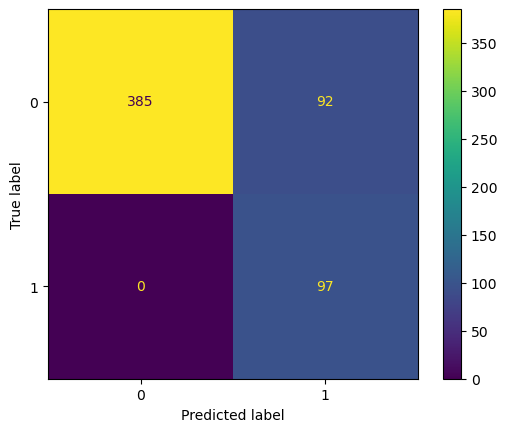

In [56]:
import statistics
from sklearn import metrics
import matplotlib.pyplot as plt
columns=len(X_train_scaled.columns)
X_train_scaled['calc_value']=X_train_scaled.apply(lambda row: row[0], axis =1)
j=0
while j < columns-2:
  X_train_scaled['calc_value']=X_train_scaled.apply(lambda row: classification(row['calc_value'], row[j+1], 0.5, 3.75, 3.75, 0.85), axis = 1)
  j += 1
X_train_scaled['calc_value_class'] = X_train_scaled.apply(lambda row: 0 if (row['calc_value']<= 0.5)else 1, axis=1)
X_train_scaled['target_class'] = X_train_scaled.apply(lambda row: 0 if (row['target']<= 0.5)else 1, axis=1)
calculate_tests(X_train_scaled[["calc_value_class"]].values, X_train_scaled[['target_class']].values)

In [57]:
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score, mean_squared_error
import math
columns=len(X_test_scaled.columns)
X_test_scaled['calc_value']=X_test_scaled.apply(lambda row: row[0], axis =1)
j=0
while j < columns-2:
  X_test_scaled['calc_value']=X_test_scaled.apply(lambda row: classification(row['calc_value'], row[j+1],  0.5, 3.75, 3.75, 0.85), axis = 1)
  j += 1
show_results(X_test_scaled, 0, 0, 0, 0, 0)

Results:
          age      fare  pclass  sex  target  calc_value  target_class  \
0    0.529412  0.201208     0.5  1.0     1.0         1.0             1   
1    0.313725  0.131152     1.0  0.0     0.0         0.0             0   
2    0.882353  0.645170     0.0  1.0     1.0         1.0             1   
3    0.431373  0.211798     0.5  0.0     0.0         0.0             0   
4    0.392157  0.123006     1.0  1.0     1.0         1.0             1   
..        ...       ...     ...  ...     ...         ...           ...   
139  0.450980  0.131152     1.0  0.0     0.0         0.0             0   
140  0.313725  0.128640     1.0  0.0     0.0         0.0             0   
141  0.411765  0.258231     1.0  1.0     1.0         1.0             1   
142  0.705882  0.509537     1.0  0.0     0.0         0.0             0   
143  0.627451  0.131152     1.0  0.0     0.0         0.0             0   

     calc_value_class  
0                   1  
1                   0  
2                   1  
3     

In [58]:
X_test_scaled['target_class'] = X_test_scaled.apply(lambda row: 0 if (row['target']<0.5)else 1, axis=1)
X_test_scaled['calc_value_class'] = X_test_scaled.apply(lambda row: 0 if (row['calc_value']< 0.5)else 1, axis=1)

In [59]:
target_values = X_test_scaled[['target_class']].values
value = X_test_scaled[['calc_value_class']].values

Accuracy score =  0.8819444444444444
F1 =  0.858128078817734
Precision =  0.9227272727272727
Recall =  0.8333333333333333


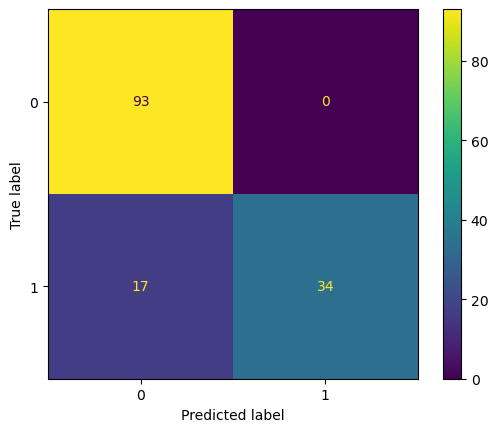

In [64]:
calculate_tests(target_values, value)

In [125]:
import numpy as np
import statistics
import itertools
from tqdm import tqdm

def error_metric(values, labels, a, kappa, lam, gamma):
    columns=len(X_test_scaled.columns)
    X_test_scaled['calc_value']=X_test_scaled.apply(lambda row: row[0], axis =1)
    j=0
    while j < columns-2:
      X_test_scaled['calc_value']=X_test_scaled.apply(lambda row: classification(row['calc_value'], row[j+1], a, kappa, lam, gamma), axis = 1)
      j += 1
    return np.mean(np.abs(X_test_scaled['calc_value'] - labels))

def grid_search(values, labels):
    a_range     = np.round(np.arange(0.1, 1.1,  0.1), 2)   # [0.0, 0.1, ..., 1.0]
    gamma_range = np.round(np.arange(0.1, 1.1,  0.1), 2)   # [0.0, 0.1, ..., 1.0]
    kappa_range = np.round(np.arange(0.1, 3.1,  0.1), 2)   # [0.0, 0.1, ..., 3.0]
    lam_range   = np.round(np.arange(0.1, 3.1,  0.1), 2)   # [0.0, 0.1, ..., 3.0]

    best_params = None
    best_error  = np.inf
    results     = []

    combos = list(itertools.product(a_range, kappa_range, lam_range, gamma_range))
    print(f"Ukupno kombinacija: {len(combos)}")

    for a, kappa, lam, gamma in tqdm(combos):
        if kappa == 0 or lam == 0:
            continue

        try:
            error = error_metric(values, labels, a, kappa, lam, gamma)
        except Exception:
            continue

        results.append({
            "a": a, "kappa": kappa, "lam": lam, "gamma": gamma,
            "error": error
        })

        if error < best_error:
            best_error  = error
            best_params = {"a": a, "kappa": kappa, "lam": lam, "gamma": gamma}

    print("\nBest params:")
    print(f"  a     = {best_params['a']}")
    print(f"  kappa = {best_params['kappa']}")
    print(f"  lam   = {best_params['lam']}")
    print(f"  gamma = {best_params['gamma']}")
    print(f"  greška (MSE) = {best_error:.6f}")

    return best_params, best_error, results

if __name__ == "__main__":
    values = X_train
    labels = y_train

    best_params, best_error, all_results = grid_search(values, labels)

Ukupno kombinacija: 90000


100%|██████████| 90000/90000 [13:33:45<00:00,  1.84it/s]        


Best params:
  a     = 0.8
  kappa = 0.1
  lam   = 0.5
  gamma = 1.0
  greška (MSE) = 0.319079


Accuracy score =  0.662020905923345
F1 =  0.4032112845138055
Precision =  0.4948532948532949
Recall =  0.4056437389770723


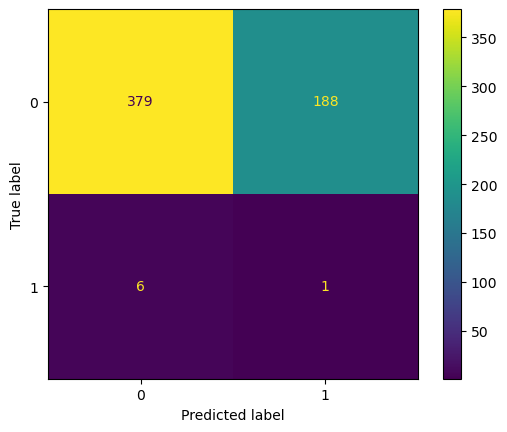

In [129]:
columns=len(X_train_scaled.columns)
X_train_scaled['calc_value']=X_train_scaled.apply(lambda row: row[0], axis =1)
j=0
while j < columns-2:
  X_train_scaled['calc_value']=X_train_scaled.apply(lambda row: classification(row['calc_value'], row[j+1], 0.8, 0.1, 0.5, 1.0), axis = 1)
  j += 1
X_train_scaled['calc_value_class'] = X_train_scaled.apply(lambda row: 0 if (row['calc_value']<= 0.5)else 1, axis=1)
X_train_scaled['target_class'] = X_train_scaled.apply(lambda row: 0 if (row['target']<= 0.5)else 1, axis=1)
calculate_tests(X_train_scaled[["calc_value_class"]].values, X_train_scaled[['target_class']].values)

Results:
          age      fare  pclass  sex  target  calc_value  target_class  \
0    0.529412  0.201208     0.5  1.0     1.0         0.0             1   
1    0.313725  0.131152     1.0  0.0     0.0         0.0             0   
2    0.882353  0.645170     0.0  1.0     1.0         0.0             1   
3    0.431373  0.211798     0.5  0.0     0.0         0.0             0   
4    0.392157  0.123006     1.0  1.0     1.0         0.0             1   
..        ...       ...     ...  ...     ...         ...           ...   
139  0.450980  0.131152     1.0  0.0     0.0         0.0             0   
140  0.313725  0.128640     1.0  0.0     0.0         0.0             0   
141  0.411765  0.258231     1.0  1.0     1.0         0.0             1   
142  0.705882  0.509537     1.0  0.0     0.0         0.0             0   
143  0.627451  0.131152     1.0  0.0     0.0         0.0             0   

     calc_value_class  
0                   1  
1                   0  
2                   0  
3     

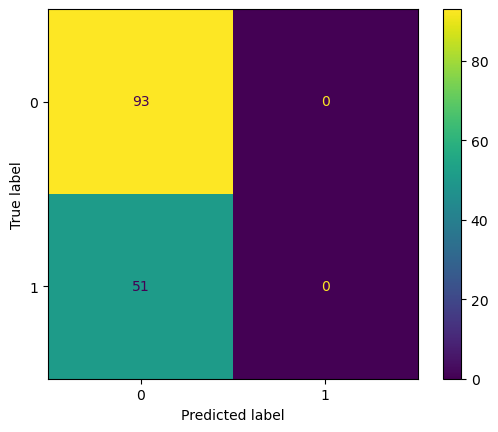

In [133]:
columns=len(X_test_scaled.columns)
X_test_scaled['calc_value']=X_test_scaled.apply(lambda row: row[0], axis =1)
j=0
while j < columns-2:
  X_test_scaled['calc_value']=X_test_scaled.apply(lambda row: classification(row['calc_value'], row[j+1],  0.8, 0.1, 0.5, 1.0), axis = 1)
  j += 1
show_results(X_test_scaled, 0, 0, 0, 0, 0)
X_test_scaled['target_class'] = X_test_scaled.apply(lambda row: 0 if (row['target']<0.8)else 1, axis=1)
X_test_scaled['calc_value_class'] = X_test_scaled.apply(lambda row: 0 if (row['calc_value']< 0.8)else 1, axis=1)
target_values = X_test_scaled[['target_class']].values
value = X_test_scaled[['calc_value_class']].values
calculate_tests(target_values, value)